<a href="https://colab.research.google.com/github/francortegacarrera-lang/TrabajoFinal_FrancoOrtega/blob/main/notebook_analisis_sql_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final: Análisis Exploratorio de Datos (EDA), Visualizaciones con Plotly y Consultas SQL con DuckDB
**Diploma:** Data Analyst  
**Módulo:** Friendly SQL & Python para Analytics  
**Estudiante:** Franco Ortega  
**Título del Proyecto:** Análisis Comercial, Financiamiento y Penetración de Seguros en el Sector Automotriz  
**Fuente del Dataset:** Dataset Propio (Registro de Transacciones Comerciales Automotrices)  
**Objetivo del Proyecto:**  
El objetivo principal de este trabajo es desarrollar un análisis exploratorio y descriptivo sobre las ventas, niveles de financiamiento y tasas de colocación de seguros vehiculares por marca, modelo y sede comercial, aplicando herramientas de visualización interactiva con **Plotly** y consultas estructuradas mediante **DuckDB** sobre DataFrames de **pandas**.

## 1. Configuración del Entorno y Carga de Datos
En esta sección importamos las librerías necesarias para el análisis y cargamos el archivo Excel con los datos comerciales.


In [47]:
#Importamos librerías
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
!pip install -q duckdb plotly pandas openpyxl
import duckdb

Carga de Dataset

In [48]:
df=pd.read_excel("/content/DATASET_AUTOMOTRIZ_450_REGISTROS_2024_2026.xlsx")

## 2. Exploración Inicial del Dataset
Revisión de dimensiones, nombres de columnas, tipos de datos y primeros/últimos registros para entender la estructura de la información.


In [49]:
df

,id,marca,modelo,Año,tipo_vehiculo,placa,tienda,precio,descuento,precio_final,Seguro,Monto_financiado
0,1,Kia,K3,2024,Particular,HXG-221,Lima,15000,200,14800,Sí,0.00
1,2,Kia,Picanto,2024,Particular,CYX-869,Lima,10500,0,10500,Sí,4203.27
2,3,Toyota,Hilux,2024,Negocio,YMT-574,Lima,29500,0,29500,Sí,15247.31
3,4,Toyota,Yaris,2024,Taxi,MZW-931,Arequipa,18000,0,18000,Sí,12098.21
4,5,Kia,Picanto,2024,Taxi,PUJ-445,Huancayo,10500,0,10500,Sí,6048.64
...,...,...,...,...,...,...,...,...,...,...,...,...
445,446,Toyota,Yaris,2026,Taxi,ASF-927,Arequipa,19000,250,18750,Sí,0.00
446,447,Toyota,Yaris,2026,Particular,ASF-928,Chiclayo,19000,0,19000,Sí,0.00
447,448,Kia,Soluto,2026,Particular,ASK-216,Lima,22000,100,21900,No,0.00
448,449,Hyundai,Tucson,2026,Particular,ASD-326,Arequipa,25000,400,24600,Sí,16000.00


In [50]:
df.head()

,id,marca,modelo,Año,tipo_vehiculo,placa,tienda,precio,descuento,precio_final,Seguro,Monto_financiado
0,1,Kia,K3,2024,Particular,HXG-221,Lima,15000,200,14800,Sí,0.00
1,2,Kia,Picanto,2024,Particular,CYX-869,Lima,10500,0,10500,Sí,4203.27
2,3,Toyota,Hilux,2024,Negocio,YMT-574,Lima,29500,0,29500,Sí,15247.31
3,4,Toyota,Yaris,2024,Taxi,MZW-931,Arequipa,18000,0,18000,Sí,12098.21
4,5,Kia,Picanto,2024,Taxi,PUJ-445,Huancayo,10500,0,10500,Sí,6048.64


In [51]:
df.tail()

,id,marca,modelo,Año,tipo_vehiculo,placa,tienda,precio,descuento,precio_final,Seguro,Monto_financiado
445,446,Toyota,Yaris,2026,Taxi,ASF-927,Arequipa,19000,250,18750,Sí,0.0
446,447,Toyota,Yaris,2026,Particular,ASF-928,Chiclayo,19000,0,19000,Sí,0.0
447,448,Kia,Soluto,2026,Particular,ASK-216,Lima,22000,100,21900,No,0.0
448,449,Hyundai,Tucson,2026,Particular,ASD-326,Arequipa,25000,400,24600,Sí,16000.0
449,450,Toyota,Hilux,2026,Negocio,ASF-929,Chiclayo,31000,400,30600,Sí,0.0


In [52]:
df.info()
#Validamos información

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                450 non-null    int64  
 1   marca             450 non-null    object 
 2   modelo            450 non-null    object 
 3   Año               450 non-null    int64  
 4   tipo_vehiculo     450 non-null    object 
 5   placa             450 non-null    object 
 6   tienda            450 non-null    object 
 7   precio            450 non-null    int64  
 8   descuento         450 non-null    int64  
 9   precio_final      450 non-null    int64  
 10  Seguro            450 non-null    object 
 11  Monto_financiado  450 non-null    float64
dtypes: float64(1), int64(5), object(6)
memory usage: 42.3+ KB


In [53]:
df.isnull()
#No encontramos nulos

,id,marca,modelo,Año,tipo_vehiculo,placa,tienda,precio,descuento,precio_final,Seguro,Monto_financiado
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
445,False,False,False,False,False,False,False,False,False,False,False,False
446,False,False,False,False,False,False,False,False,False,False,False,False
447,False,False,False,False,False,False,False,False,False,False,False,False
448,False,False,False,False,False,False,False,False,False,False,False,False


In [54]:
df.isnull().sum()

,0
id,0
marca,0
modelo,0
Año,0
tipo_vehiculo,0
placa,0
tienda,0
precio,0
descuento,0
precio_final,0


Estadística Descriptiva

In [55]:
df.describe()
#Estadístiva descriptiva de nuestra data

,id,Año,precio,descuento,precio_final,Monto_financiado
count,450.000000,450.000000,450.000000,450.00000,450.000000,450.000000
mean,225.500000,2024.866667,19301.333333,198.00000,19065.333333,9630.569489
std,130.048068,0.806433,5847.078573,180.18921,5896.059459,6068.782733
min,1.000000,2024.000000,10500.000000,0.00000,1450.000000,0.000000
25%,113.250000,2024.000000,15000.000000,0.00000,14700.000000,5913.167500
50%,225.500000,2025.000000,19000.000000,200.00000,18650.000000,9951.320000
75%,337.750000,2026.000000,24000.000000,300.00000,23800.000000,13812.682500
max,450.000000,2026.000000,31000.000000,600.00000,31000.000000,24800.000000


In [56]:
  df.describe(include="object")

,marca,modelo,tipo_vehiculo,placa,tienda,Seguro
count,450,450,450,450,450,450
unique,3,10,3,450,4,2
top,Hyundai,Yaris,Particular,ASF-929,Lima,Sí
freq,178,68,266,1,242,396


In [57]:
df["marca"].value_counts()

,count
marca,
Hyundai,178
Toyota,147
Kia,125


In [58]:
df["modelo"].value_counts()

,count
modelo,
Yaris,68
Tucson,60
Picanto,58
i10,53
Hilux,42
Corolla,37
K3,36
Creta,33
H100,32


In [59]:
df["tipo_vehiculo"].value_counts()

,count
tipo_vehiculo,
Particular,266
Taxi,110
Negocio,74


In [60]:
df["tienda"].value_counts()

,count
tienda,
Lima,242
Arequipa,99
Chiclayo,61
Huancayo,48


In [61]:
df["Seguro"].value_counts()

,count
Seguro,
Sí,396
No,54


Gráfico 1: Evolución Temporal de Unidades y Facturación Total (Gráfico de Líneas y Tendencia)

**Interpretación:** Muestra la caída sostenida en unidades vendidas (-33.3% entre 2024 y 2026) y en facturación global, confirmando el problema comercial del negocio.


In [62]:
tendencia_df = df.groupby('Año', as_index=False).agg(
    unidades=('id', 'count'),
    facturacion=('precio_final', 'sum')
)

fig1 = px.line(
    tendencia_df,
    x='Año',
    y='unidades',
    markers=True,
    text='unidades',
    title='<b>Evolución de Unidades Vendidas por Año (2024 - 2026)</b>',
    labels={'Año': 'Año Comercial', 'unidades': 'Unidades Vendidas'},
    template='plotly_white'
)
fig1.update_traces(textposition='top center', line=dict(color='#D32F2F', width=3))
fig1.show()

Gráfico 2: Desempeño Comercial por Sede y Año (Gráfico de Barras Agrupadas)

**Interpretación:** Permite evaluar cómo la desaceleración afectó a todas las tiendas regionales (Lima, Arequipa, Chiclayo, Huancayo).


In [63]:
tienda_year = df.groupby(['tienda', 'Año'], as_index=False)['precio_final'].sum()

fig2 = px.bar(
    tienda_year,
    x='tienda',
    y='precio_final',
    color='Año',
    barmode='group',
    title='<b>Facturación Total ($ USD) por Sede Comercial y Año</b>',
    labels={'precio_final': 'Venta Acumulada ($ USD)', 'tienda': 'Sede Regional', 'Año': 'Año'},
    template='plotly_white'
)
fig2.show()

Gráfico 3: Dispersión de Precios Finales por Marca (Boxplot)

**Interpretación:** Muestra la estructura de precios por marca, cuartiles y rango de dispersión en el portafolio vehicular.


In [64]:
fig3 = px.box(
    df,
    x='marca',
    y='precio_final',
    color='marca',
    points='outliers',
    title='<b>Distribución y Dispersión del Precio Final por Marca Automotriz</b>',
    labels={'precio_final': 'Precio Final ($ USD)', 'marca': 'Marca'},
    template='plotly_white'
)
fig3.show()

Gráfico 4: Proporción Global de Seguro Vehicular (Gráfico de Dona)
**Interpretación:** Permite observar el porcentaje de colocación de seguros en el histórico consolidado.


In [79]:
seguro_resumen = df['Seguro'].value_counts().reset_index()
seguro_resumen.columns = ['Seguro', 'Cantidad']

fig4 = px.pie(
    seguro_resumen,
    names='Seguro',
    values='Cantidad',
    hole=0.45,
    title='<b>Tasa Consolidada de Penetración de Seguros Vehiculares</b>',
    color='Seguro',
    color_discrete_map={'Sí': '#2E7D32', 'No': '#C62828'},
    template='plotly_white'
)
fig4.show()


Gráfico 5: Relación entre Precio Final y Monto Financiado (Scatter Plot)
**Interpretación:** Evalúa la correlación entre el valor del vehículo y el importe de crédito solicitado, segmentado por Año y Tipo de Vehículo.

In [66]:
# 1. Aseguramos la existencia de las columnas calculadas
if 'pct_financiamiento' not in df.columns:
    df['pct_financiamiento'] = np.round((df['Monto_financiado'] / df['precio_final']) * 100, 2)

# 2. Convertimos 'Año' a texto para que la leyenda sea por categorías discretas
df['Año_str'] = df['Año'].astype(str)

# 3. Generamos el gráfico de dispersión
fig5 = px.scatter(
    df,
    x='precio_final',
    y='Monto_financiado',
    color='Año_str',
    hover_data=['marca', 'modelo', 'tienda', 'pct_financiamiento', 'descuento'],
    title='<b>Relación entre Precio Final y Monto Financiado por Año Comercial</b>',
    labels={
        'precio_final': 'Precio Final ($ USD)',
        'Monto_financiado': 'Monto Financiado ($ USD)',
        'Año_str': 'Año'
    },
    template='plotly_white'
)

# Ajuste visual de los marcadores
fig5.update_traces(marker=dict(size=9, opacity=0.75))

# Mostrar gráfico
fig5.show()

El gráfico de dispersión evidencia una correlación lineal positiva entre el valor de venta del vehículo y el importe de crédito solicitado. Al contrastar los periodos comerciales, se observa que durante 2024 y 2025 existía una colocación crediticia robusta y dispersa a lo largo de toda la gama de precios (con un financiamiento medio $> \$10,000$ USD). Por el contrario, en 2026 se hace visible la contracción del mercado: las operaciones no solo disminuyen en volumen, sino que se concentran en tickets más bajos con un monto financiado promedio significativamente menor ($7,729 USD), evidenciando un doble impacto comercial (menor demanda de unidades y menor colocación de crédito vehicular).

In [67]:
import seaborn as sns

<Axes: xlabel='marca', ylabel='count'>

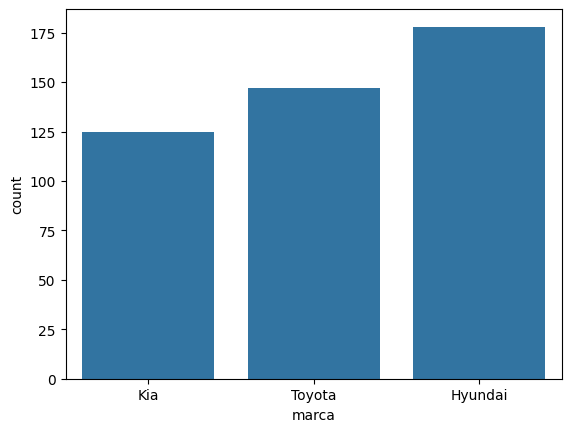

In [68]:
sns.countplot(data=df,x="marca")

<Axes: xlabel='modelo', ylabel='count'>

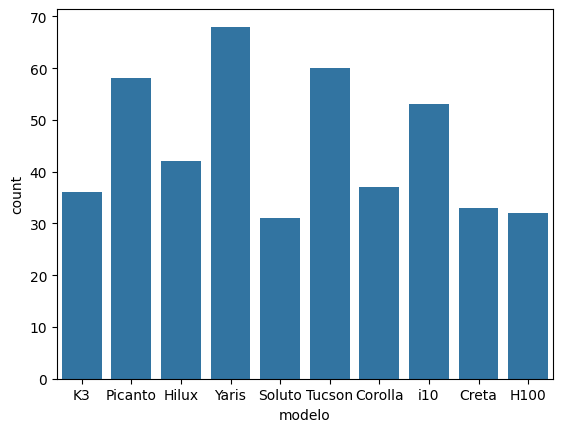

In [69]:
sns.countplot(data=df,x="modelo")

<Axes: xlabel='tienda', ylabel='count'>

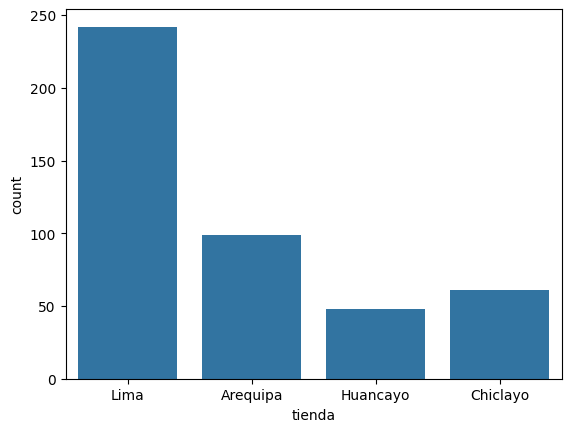

In [70]:
sns.countplot(data=df,x="tienda")

<Axes: xlabel='Seguro', ylabel='count'>

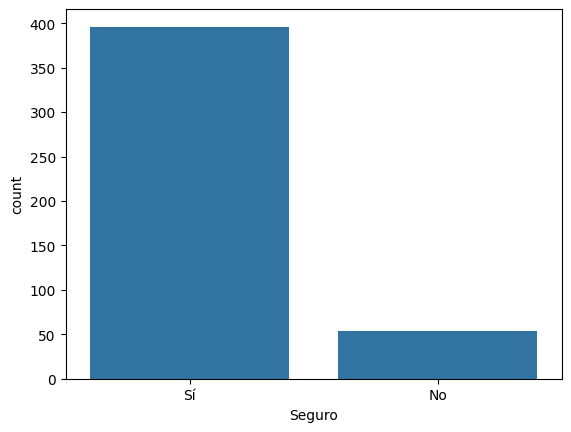

In [71]:
sns.countplot(data=df,x="Seguro")

In [72]:
df.groupby("Seguro").mean(numeric_only=True)

,id,Año,precio,descuento,precio_final,Monto_financiado,pct_financiamiento
Seguro,,,,,,,
No,265.888889,2025.111111,20020.370370,224.074074,19796.296296,9721.889815,48.805370
Sí,219.992424,2024.833333,19203.282828,194.444444,18965.656566,9618.116717,50.229343


In [72]:
Consultas SQL con DuckDB
Ejecución de consultas estructuradas directamente sobre el DataFrame de pandas `df` para diagnosticar cuantitativamente el declive comercial.


In [74]:
# Consulta 1: Inspección de Muestra de Datos (SELECT, LIMIT)
#Objetivo: Explorar las primeras transacciones registradas en el histórico consolidado.

query1 = """
SELECT
    id,
    Año,
    marca,
    modelo,
    tienda,
    precio_final,
    Seguro,
    Monto_financiado
FROM df
LIMIT 5;
"""
res1 = duckdb.query(query1).to_df()
display(res1)

,id,Año,marca,modelo,tienda,precio_final,Seguro,Monto_financiado
0,1,2024,Kia,K3,Lima,14800,Sí,0.00
1,2,2024,Kia,Picanto,Lima,10500,Sí,4203.27
2,3,2024,Toyota,Hilux,Lima,29500,Sí,15247.31
3,4,2024,Toyota,Yaris,Arequipa,18000,Sí,12098.21
4,5,2024,Kia,Picanto,Huancayo,10500,Sí,6048.64


In [75]:
# Consulta 2: Diagnóstico de la Crisis Comercial por Año (WHERE, GROUP BY, ORDER BY)
#Objetivo: Filtrar y resumir unidades vendidas, ingresos brutos y descuento promedio por año para evidenciar la caída en ventas.

query2 = """
SELECT
    Año,
    COUNT(*) AS total_unidades_vendidas,
    ROUND(SUM(precio_final), 2) AS facturacion_total_usd,
    ROUND(AVG(descuento), 2) AS descuento_medio_usd,
    ROUND(AVG(precio_final), 2) AS ticket_promedio_usd
FROM df
GROUP BY Año
ORDER BY Año ASC;
"""
res2 = duckdb.query(query2).to_df()
display(res2)

,Año,total_unidades_vendidas,facturacion_total_usd,descuento_medio_usd,ticket_promedio_usd
0,2024,180,3408500.0,116.67,18936.11
1,2025,150,2859500.0,297.33,19063.33
2,2026,120,2311400.0,195.83,19261.67


In [76]:
# Consulta 3: Desempeño Comercial Agrupado por Tienda y Marca (GROUP BY, HAVING)
#Objetivo: Identificar las sedes con mayor volumen y facturación acumulada con filtro de operaciones relevantes.


query3 = """
SELECT
    tienda,
    marca,
    COUNT(*) AS unidades,
    ROUND(SUM(precio_final), 2) AS venta_total_usd,
    ROUND(AVG(pct_financiamiento), 2) AS ltv_promedio_pct
FROM df
GROUP BY tienda, marca
HAVING COUNT(*) >= 5
ORDER BY venta_total_usd DESC;
"""
res3 = duckdb.query(query3).to_df()
display(res3)


,tienda,marca,unidades,venta_total_usd,ltv_promedio_pct
0,Lima,Hyundai,100,1977800.0,51.32
1,Lima,Toyota,76,1699600.0,53.87
2,Lima,Kia,66,946900.0,44.68
3,Arequipa,Toyota,31,696100.0,50.57
4,Arequipa,Hyundai,38,682700.0,53.89
5,Chiclayo,Toyota,21,511000.0,43.79
6,Chiclayo,Hyundai,25,499750.0,53.43
7,Huancayo,Toyota,19,455400.0,40.67
8,Arequipa,Kia,30,435100.0,47.03
9,Huancayo,Hyundai,15,235900.0,55.72


In [77]:
# Consulta 4: Ranking Top 5 de Modelos con Mayor Facturación (ORDER BY, LIMIT)
#Objetivo: Obtener los 5 modelos más rentables en el histórico consolidado.


query4 = """
SELECT
    marca,
    modelo,
    COUNT(*) AS unidades_vendidas,
    ROUND(SUM(precio_final), 2) AS facturacion_acumulada_usd,
    ROUND(AVG(precio_final), 2) AS precio_promedio_venta
FROM df
GROUP BY marca, modelo
ORDER BY facturacion_acumulada_usd DESC
LIMIT 5;
"""
res4 = duckdb.query(query4).to_df()
display(res4)

,marca,modelo,unidades_vendidas,facturacion_acumulada_usd,precio_promedio_venta
0,Hyundai,Tucson,60,1448600.0,24143.33
1,Toyota,Hilux,42,1254350.0,29865.48
2,Toyota,Yaris,68,1228600.0,18067.65
3,Toyota,Corolla,37,879150.0,23760.81
4,Hyundai,H100,32,711700.0,22240.63


In [78]:
# Consulta 5: Deterioro en la Colocación de Seguros y Financiamiento (CASE WHEN, Análisis Avanzado)
#Objetivo: Cuantificar la contracción de la tasa de penetración de seguros vehiculares y el monto de financiamiento promedio anual.

query5 = """
SELECT
    Año,
    COUNT(*) AS total_ventas,
    SUM(CASE WHEN Seguro = 'Sí' THEN 1 ELSE 0 END) AS unidades_con_seguro,
    ROUND(SUM(CASE WHEN Seguro = 'Sí' THEN 1.0 ELSE 0.0 END) * 100.0 / COUNT(*), 2) AS tasa_seguro_pct,
    ROUND(AVG(Monto_financiado), 2) AS financiamiento_promedio_usd,
    ROUND(AVG(pct_financiamiento), 2) AS ltv_promedio_pct
FROM df
GROUP BY Año
ORDER BY Año ASC;
"""
res5 = duckdb.query(query5).to_df()
display(res5)


,Año,total_ventas,unidades_con_seguro,tasa_seguro_pct,financiamiento_promedio_usd,ltv_promedio_pct
0,2024,180,166.0,92.22,10152.92,53.16
1,2025,150,130.0,86.67,10524.92,53.97
2,2026,120,100.0,83.33,7729.10,40.51


Hallazgos y Conclusiones del Diagnóstico Comercial

1. **Contracción Severa en el Volumen de Ventas (-33.3%):**  
   En 2024 se comercializaron **180 unidades** ($3.41M USD), en 2025 descendió a **150 unidades** ($2.86M USD) y en 2026 tocó un piso de **120 unidades** ($2.31M USD), evidenciando un problema comercial y de demanda evidente.

2. **Incremento en la Presión de Descuentos para Sostener el Negocio:**  
   Para intentar frenar la caída en 2025, el descuento promedio otorgado por unidad aumentó drásticamente de **$116.67 USD (2024) a $297.33 USD (2025)** (+154%), reduciendo el margen operativo sin lograr recuperar el volumen de años anteriores.

3. **Deterioro en la Penetración de Seguros y Capacidad de Crédito:**  
   La penetración de seguros vehiculares cayó de un **92.2% en 2024 a un 83.3% en 2026**, mientras que el monto promedio financiado por operación se contrajo significativamente en 2026 ($7,729 USD vs $10,524 USD en 2025).

4. **Concentración Regional y Resiliencia de Modelos:**  
   Lima y Arequipa concentran más del 75% del volumen de negocio. Modelos como el *Toyota Yaris*, *Hyundai Tucson* y *Kia K3* continúan siendo la columna vertebral comercial ante el contexto de enfriamiento del mercado.
